# Loan Approval Prediction System
End-to-end ML pipeline: cleaning → EDA → feature engineering → model comparison → tuning → threshold optimisation → evaluation → explainability → fairness audit.

**Run:** `Kernel → Restart & Run All` (from the `notebooks/` folder). Data is read from `../data/`, figures are saved to `../reports/figures/`, metrics to `../results/`.

In [1]:
import json, os, warnings
import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score, roc_auc_score,
                             average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, roc_curve, precision_recall_curve, matthews_corrcoef)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
from pathlib import Path
try:
    ROOT = Path(__file__).resolve().parent.parent          # repo root (this script lives in src/)
except NameError:                                           # running inside a notebook
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR, FIG = ROOT / "data", ROOT / "reports" / "figures"
RES_DIR, MODEL_DIR = ROOT / "results", ROOT / "models"
for _d in (FIG, RES_DIR, MODEL_DIR):
    _d.mkdir(parents=True, exist_ok=True)
SEED = 42
sns.set_theme(style="whitegrid", font_scale=1.0)
C_YES, C_NO, C_MAIN = "#2E7D32", "#C62828", "#1F3864"

def save(name):
    plt.tight_layout(); plt.savefig(FIG / name, dpi=150, bbox_inches="tight"); plt.show()

## 1. LOAD & CLEAN

In [2]:
raw = pd.read_csv(DATA_DIR / "loan_approval_data.csv")
print(f"Raw shape: {raw.shape}")
missing_raw = raw.isna().sum()
df = raw.dropna(subset=["Loan_Approved"]).drop(columns=["Applicant_ID"]).reset_index(drop=True)
df["y"] = (df["Loan_Approved"] == "Yes").astype(int)
print(f"After dropping unlabeled rows: {df.shape} | approval rate = {df.y.mean():.1%}")

Raw shape: (1000, 20)
After dropping unlabeled rows: (950, 20) | approval rate = 31.4%


## 2. EDA

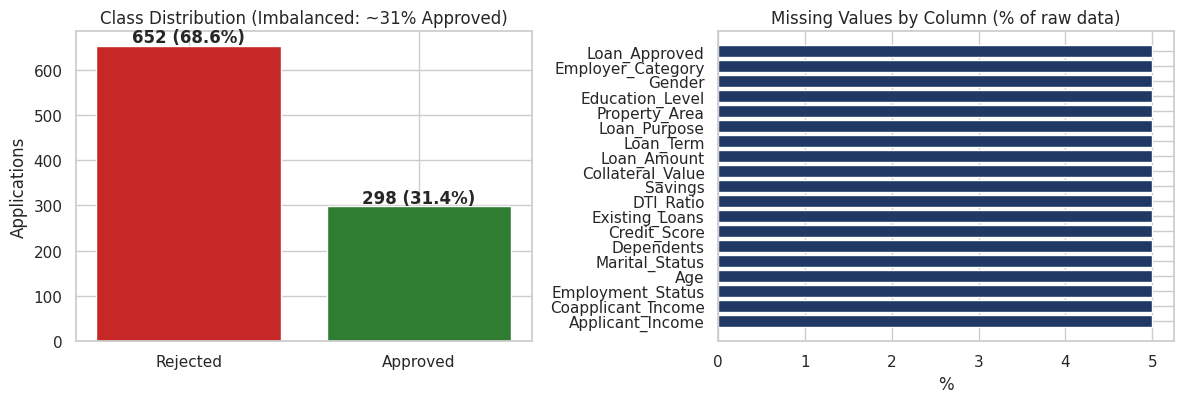

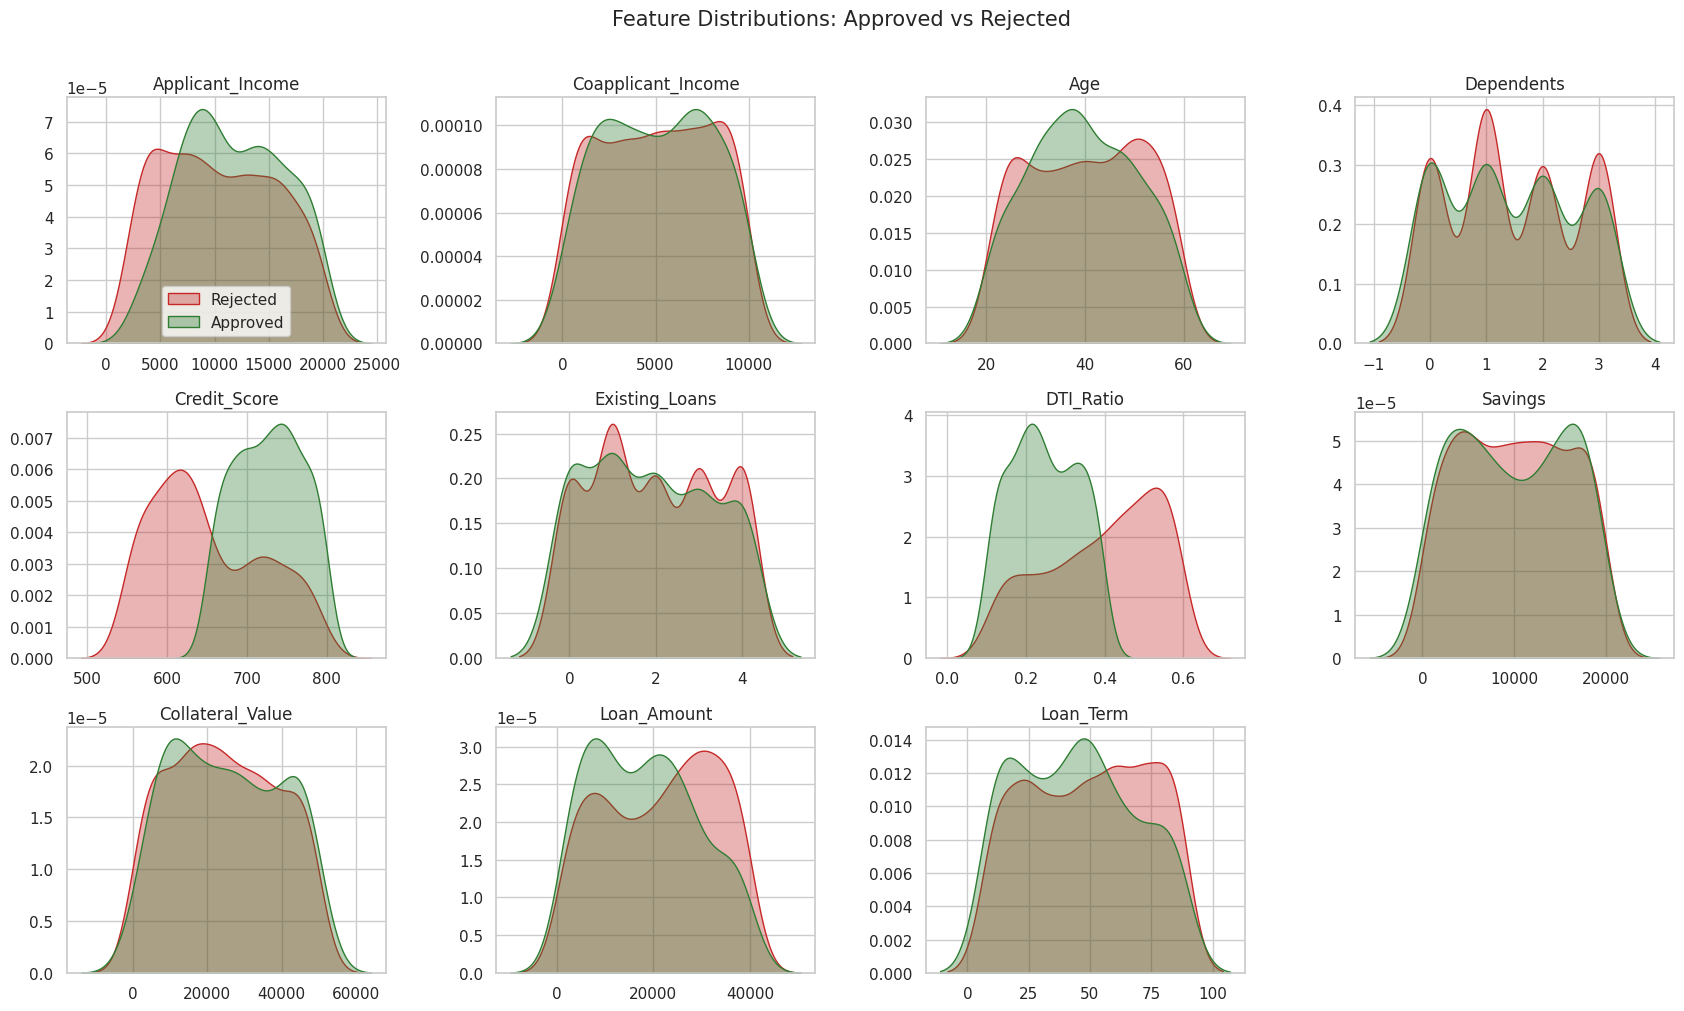

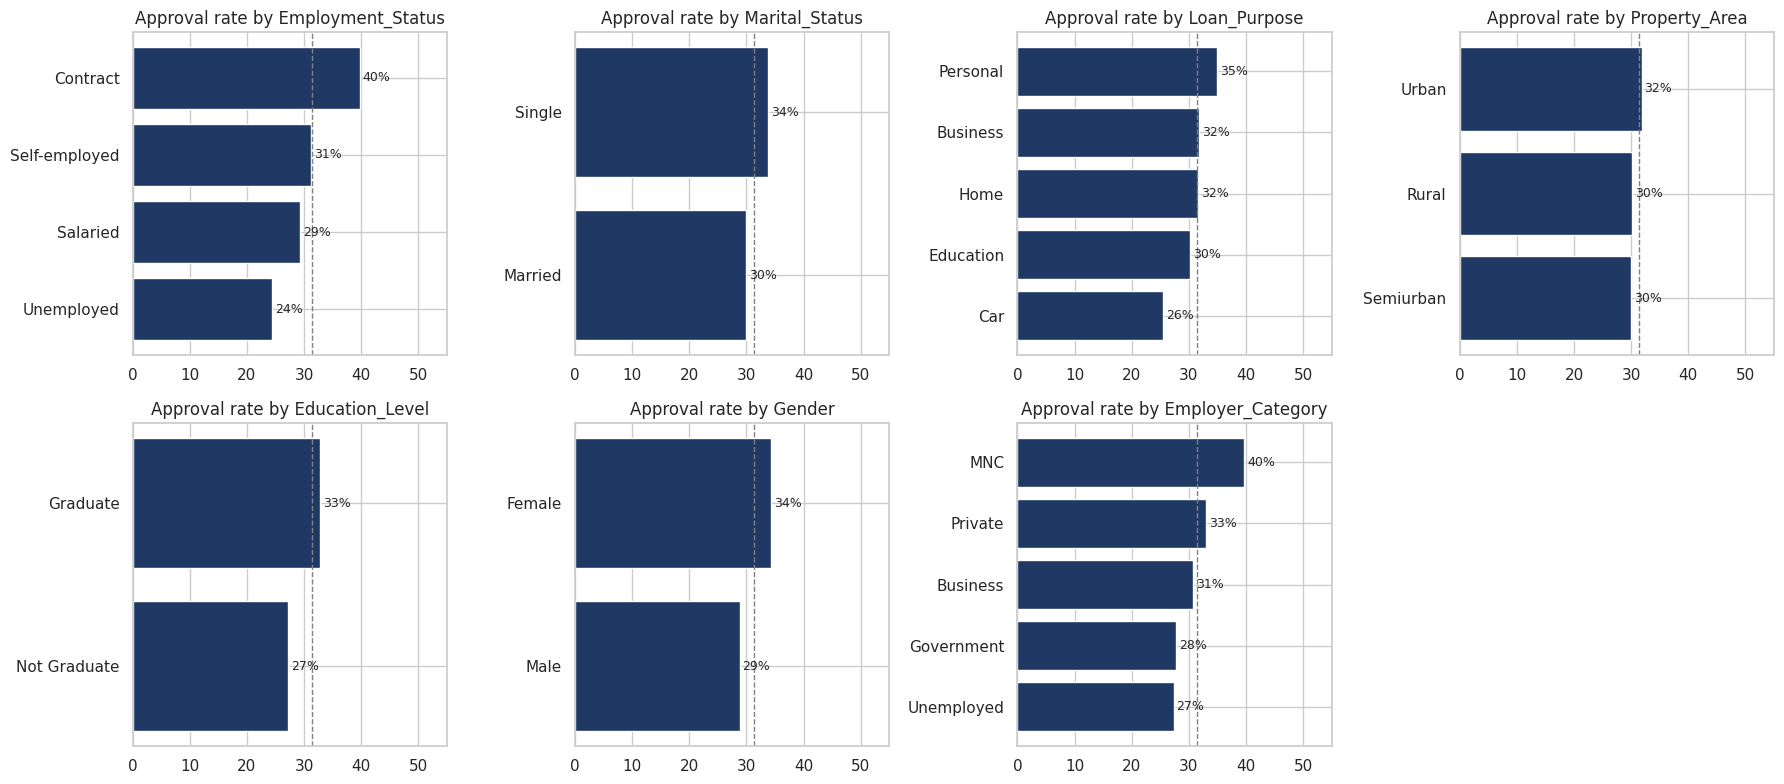

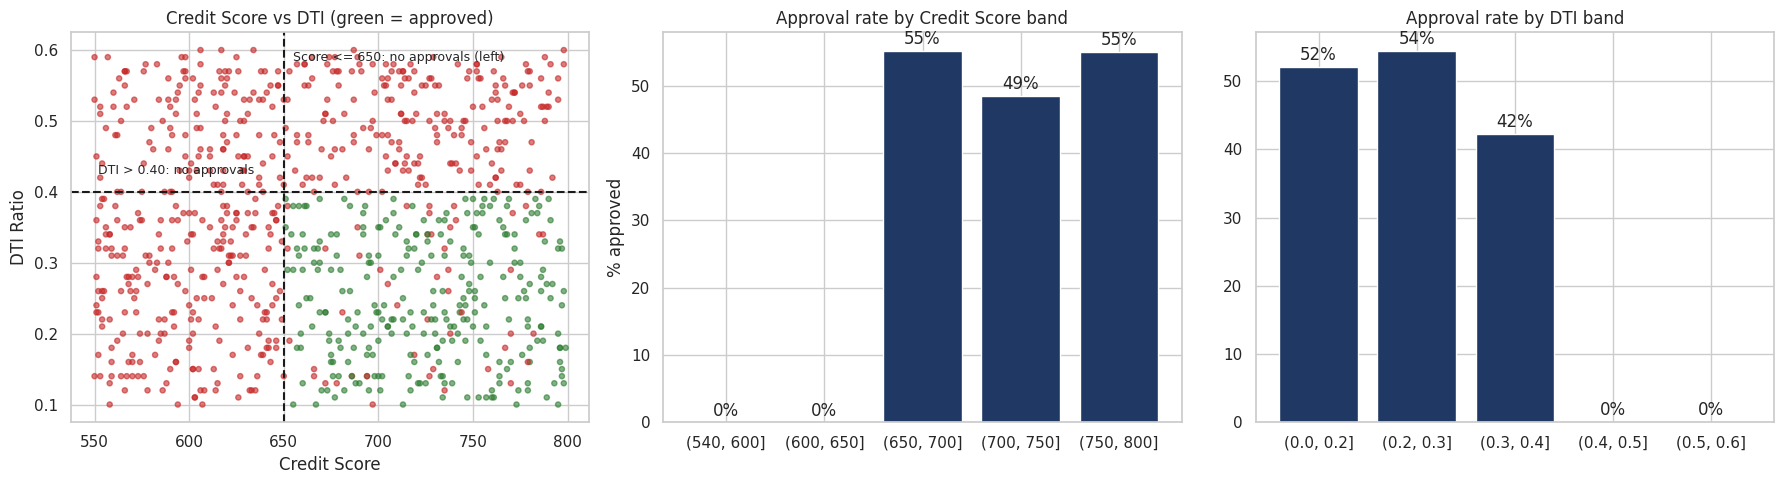

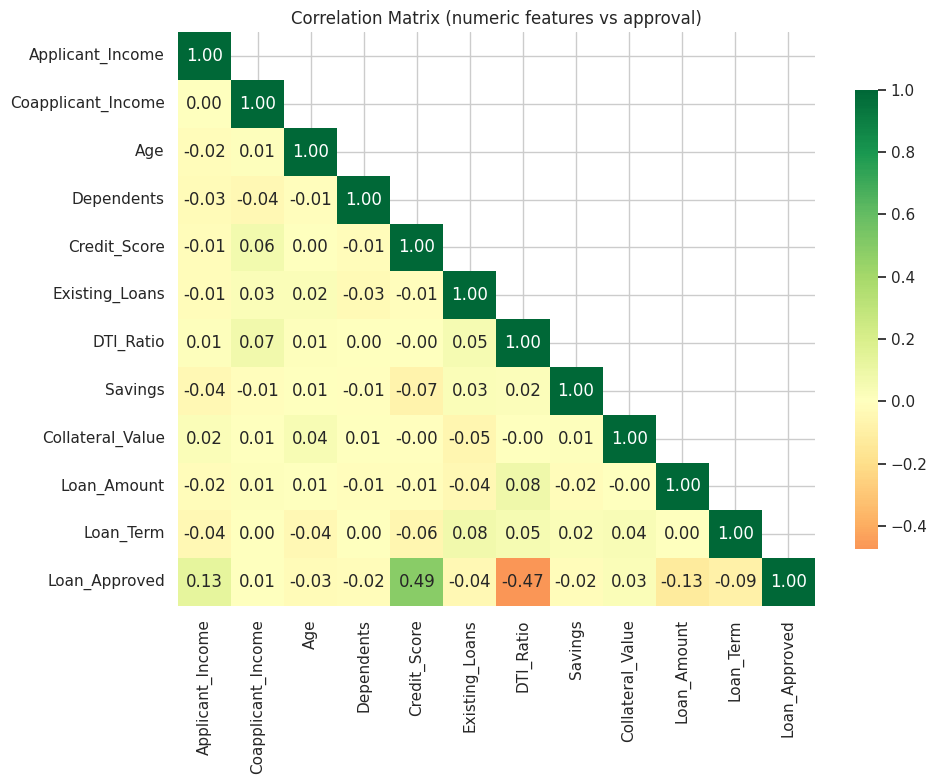

In [3]:
NUM = ["Applicant_Income", "Coapplicant_Income", "Age", "Dependents", "Credit_Score", "Existing_Loans",
       "DTI_Ratio", "Savings", "Collateral_Value", "Loan_Amount", "Loan_Term"]
CAT = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Education_Level",
       "Gender", "Employer_Category"]

# 2.1 target balance + missing values
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
cnt = df.Loan_Approved.value_counts()
ax[0].bar(["Rejected", "Approved"], [cnt["No"], cnt["Yes"]], color=[C_NO, C_YES])
for i, v in enumerate([cnt["No"], cnt["Yes"]]):
    ax[0].text(i, v + 8, f"{v} ({v/len(df):.1%})", ha="center", fontweight="bold")
ax[0].set_title("Class Distribution (Imbalanced: ~31% Approved)"); ax[0].set_ylabel("Applications")
m = (missing_raw.drop("Applicant_ID") / len(raw) * 100).sort_values()
ax[1].barh(m.index, m.values, color=C_MAIN); ax[1].set_title("Missing Values by Column (% of raw data)")
ax[1].set_xlabel("%")
save("01_class_balance_missing.png")

# 2.2 numeric distributions by outcome
fig, axes = plt.subplots(3, 4, figsize=(17, 10)); axes = axes.ravel()
for a, c in zip(axes, NUM):
    for lab, col in [(0, C_NO), (1, C_YES)]:
        sns.kdeplot(df.loc[df.y == lab, c].dropna(), ax=a, color=col, fill=True, alpha=.35,
                    label="Approved" if lab else "Rejected", warn_singular=False)
    a.set_title(c); a.set_xlabel(""); a.set_ylabel("")
axes[0].legend()
axes[-1].axis("off")
fig.suptitle("Feature Distributions: Approved vs Rejected", fontsize=15, y=1.01)
save("02_numeric_distributions.png")

# 2.3 approval rate by categorical features
fig, axes = plt.subplots(2, 4, figsize=(18, 8)); axes = axes.ravel()
for a, c in zip(axes, CAT):
    g = df.groupby(c).y.mean().sort_values() * 100
    a.barh(g.index, g.values, color=C_MAIN)
    for i, v in enumerate(g.values): a.text(v + .5, i, f"{v:.0f}%", va="center", fontsize=9)
    a.axvline(df.y.mean() * 100, color="grey", ls="--", lw=1); a.set_title(f"Approval rate by {c}")
    a.set_xlim(0, max(55, g.max() + 10))
axes[-1].axis("off")
save("03_categorical_approval_rates.png")

# 2.4 credit score & DTI: policy zones
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sc = df.dropna(subset=["Credit_Score", "DTI_Ratio"])
ax[0].scatter(sc.Credit_Score, sc.DTI_Ratio, c=np.where(sc.y == 1, C_YES, C_NO), s=14, alpha=.6)
ax[0].axvline(650, color="k", ls="--"); ax[0].axhline(0.40, color="k", ls="--")
ax[0].set_xlabel("Credit Score"); ax[0].set_ylabel("DTI Ratio"); ax[0].set_title("Credit Score vs DTI (green = approved)")
ax[0].text(552, 0.425, "DTI > 0.40: no approvals", fontsize=9); ax[0].text(655, 0.585, "Score <= 650: no approvals (left)", fontsize=9, ha="left")
cs = df.dropna(subset=["Credit_Score"]).copy()
cs["band"] = pd.cut(cs.Credit_Score, [540, 600, 650, 700, 750, 800])
b = cs.groupby("band", observed=True).y.mean() * 100
ax[1].bar(b.index.astype(str), b.values, color=C_MAIN); ax[1].set_title("Approval rate by Credit Score band")
ax[1].set_ylabel("% approved")
for i, v in enumerate(b.values): ax[1].text(i, v + 1, f"{v:.0f}%", ha="center")
dt = df.dropna(subset=["DTI_Ratio"]).copy()
dt["band"] = pd.cut(dt.DTI_Ratio, [0, .2, .3, .4, .5, .6])
b = dt.groupby("band", observed=True).y.mean() * 100
ax[2].bar(b.index.astype(str), b.values, color=C_MAIN); ax[2].set_title("Approval rate by DTI band")
for i, v in enumerate(b.values): ax[2].text(i, v + 1, f"{v:.0f}%", ha="center")
save("04_credit_score_dti_policy_zones.png")

# 2.5 correlation heat-map
corr = df[NUM + ["y"]].rename(columns={"y": "Loan_Approved"}).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, mask=np.triu(np.ones_like(corr, dtype=bool), 1),
            cbar_kws={"shrink": .8})
plt.title("Correlation Matrix (numeric features vs approval)")
save("05_correlation_heatmap.png")

## 3. FEATURE ENGINEERING

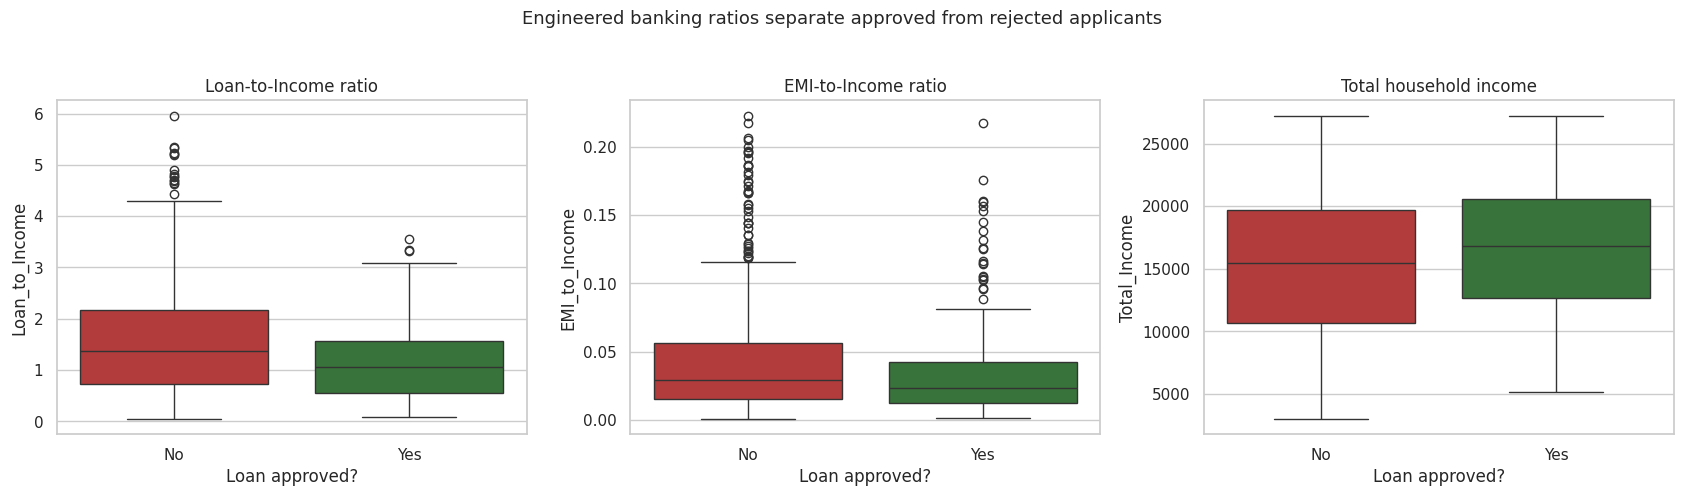

In [4]:
def add_features(d):
    d = d.copy()
    d["Total_Income"] = d.Applicant_Income + d.Coapplicant_Income
    d["Loan_to_Income"] = d.Loan_Amount / d.Total_Income
    d["Approx_EMI"] = d.Loan_Amount / d.Loan_Term                 # principal / tenure (interest ignored)
    d["EMI_to_Income"] = d.Approx_EMI / d.Total_Income
    d["Collateral_Coverage"] = d.Collateral_Value / d.Loan_Amount
    d["Savings_to_Loan"] = d.Savings / d.Loan_Amount
    d["Income_per_Dependent"] = d.Total_Income / (d.Dependents + 1)
    return d

ENG = ["Total_Income", "Loan_to_Income", "Approx_EMI", "EMI_to_Income", "Collateral_Coverage",
       "Savings_to_Loan", "Income_per_Dependent"]
df = add_features(df)

fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
for a, c, t in zip(ax, ["Loan_to_Income", "EMI_to_Income", "Total_Income"],
                   ["Loan-to-Income ratio", "EMI-to-Income ratio", "Total household income"]):
    d = df.dropna(subset=[c]); d = d[d[c] < d[c].quantile(.98)]
    sns.boxplot(data=d, x="Loan_Approved", y=c, order=["No", "Yes"], palette=[C_NO, C_YES], ax=a)
    a.set_title(t); a.set_xlabel("Loan approved?")
fig.suptitle("Engineered banking ratios separate approved from rejected applicants", y=1.03, fontsize=13)
save("06_engineered_features.png")

# Gender is a protected attribute -> excluded from the model, audited afterwards.
MODEL_NUM = [c for c in NUM + ENG]
MODEL_CAT = [c for c in CAT if c != "Gender"]
BASE_NUM = NUM

def make_pre(num_cols, cat_cols):
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_cols),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols)])

## 4. SPLIT

In [5]:
X, y = df.drop(columns=["y", "Loan_Approved"]), df["y"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print(f"Train {X_tr.shape} | Test {X_te.shape} | train approval rate {y_tr.mean():.1%}, test {y_te.mean():.1%}")
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

Train (760, 25) | Test (190, 25) | train approval rate 31.3%, test 31.6%


## 5. MODELS + TUNING

Logistic Regression  CV F1 = 0.792 ± 0.009


Decision Tree        CV F1 = 0.920 ± 0.030


Random Forest        CV F1 = 0.937 ± 0.020


Gradient Boosting    CV F1 = 0.934 ± 0.026


SVM (RBF)            CV F1 = 0.808 ± 0.026

Best model by CV F1: Random Forest


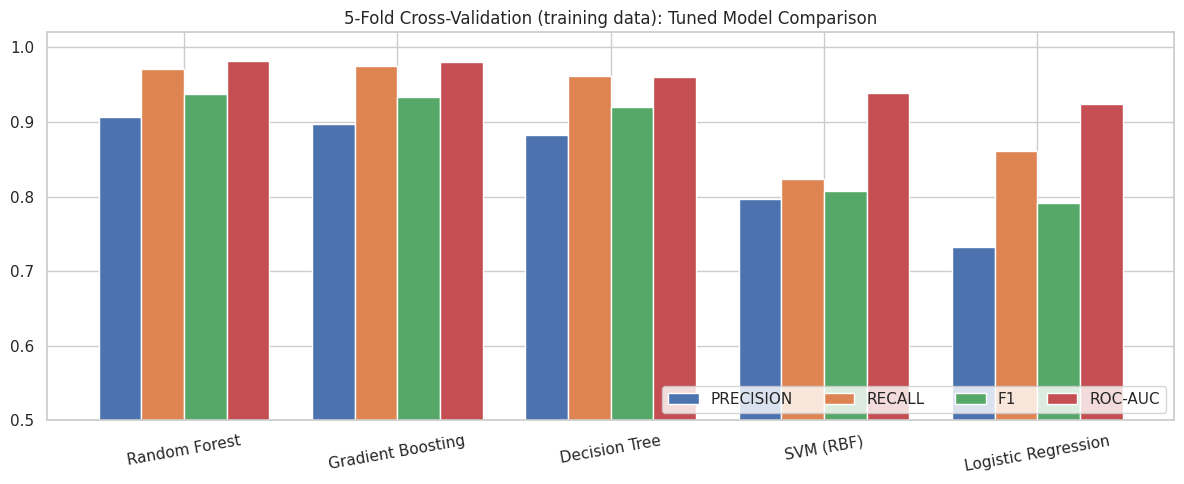

In [6]:
candidates = {
    "Logistic Regression": (LogisticRegression(class_weight="balanced", max_iter=3000, random_state=SEED),
                            {"clf__C": loguniform(1e-2, 1e2)}),
    "Decision Tree": (DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
                      {"clf__max_depth": randint(2, 8), "clf__min_samples_leaf": randint(2, 25)}),
    "Random Forest": (RandomForestClassifier(class_weight="balanced_subsample", random_state=SEED, n_jobs=-1),
                      {"clf__n_estimators": randint(150, 500), "clf__max_depth": [3, 4, 5, 6, 8, None],
                       "clf__min_samples_leaf": randint(1, 10), "clf__max_features": ["sqrt", 0.5, 0.8]}),
    "Gradient Boosting": (HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED),
                          {"clf__learning_rate": loguniform(0.02, 0.3), "clf__max_depth": [2, 3, 4, None],
                           "clf__max_iter": randint(80, 400), "clf__min_samples_leaf": randint(5, 40),
                           "clf__l2_regularization": loguniform(1e-3, 10)}),
    "SVM (RBF)": (SVC(probability=True, class_weight="balanced", random_state=SEED),
                  {"clf__C": loguniform(1e-1, 1e2), "clf__gamma": loguniform(1e-3, 1)}),
}

tuned, rows = {}, []
for name, (est, space) in candidates.items():
    pipe = Pipeline([("pre", make_pre(MODEL_NUM, MODEL_CAT)), ("clf", est)])
    rs = RandomizedSearchCV(pipe, space, n_iter=25, scoring="f1", cv=cv, random_state=SEED, n_jobs=-1, refit=True)
    rs.fit(X_tr, y_tr)
    tuned[name] = rs.best_estimator_
    cvr = cross_validate(rs.best_estimator_, X_tr, y_tr, cv=StratifiedKFold(5, shuffle=True, random_state=7),
                         scoring=["precision", "recall", "f1", "roc_auc", "average_precision"])
    rows.append({"Model": name, **{k: cvr[f"test_{k}"].mean() for k in ["precision", "recall", "f1", "roc_auc", "average_precision"]},
                 "f1_std": cvr["test_f1"].std(), "best_params": {k.replace("clf__", ""): (round(v, 4) if isinstance(v, float) else v) for k, v in rs.best_params_.items()}})
    print(f"{name:20s} CV F1 = {cvr['test_f1'].mean():.3f} ± {cvr['test_f1'].std():.3f}")
cv_table = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
best_name = cv_table.loc[0, "Model"]
print("\nBest model by CV F1:", best_name)

# CV comparison chart
fig, ax = plt.subplots(figsize=(12, 5))
mets = ["precision", "recall", "f1", "roc_auc"]
w = .2
for i, mt in enumerate(mets):
    ax.bar(np.arange(len(cv_table)) + i * w, cv_table[mt], w, label=mt.upper() if mt != "roc_auc" else "ROC-AUC")
ax.set_xticks(np.arange(len(cv_table)) + 1.5 * w); ax.set_xticklabels(cv_table.Model, rotation=10)
ax.set_ylim(0.5, 1.02); ax.set_title("5-Fold Cross-Validation (training data): Tuned Model Comparison"); ax.legend(ncol=4, loc="lower right")
save("07_model_comparison_cv.png")

## 6. THRESHOLD OPTIMISATION (train OOF only)

Optimal decision threshold (max OOF F1 on train) = 0.35


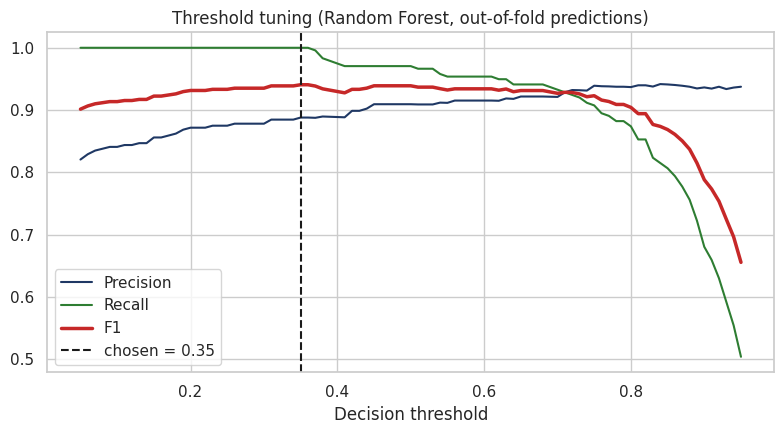

In [7]:
best = tuned[best_name]
oof = cross_val_predict(best, X_tr, y_tr, cv=cv, method="predict_proba")[:, 1]
ths = np.linspace(0.05, 0.95, 91)
f1s = [f1_score(y_tr, oof >= t) for t in ths]
thr = float(ths[int(np.argmax(f1s))])
print(f"Optimal decision threshold (max OOF F1 on train) = {thr:.2f}")
plt.figure(figsize=(8, 4.5))
plt.plot(ths, [precision_score(y_tr, oof >= t, zero_division=0) for t in ths], label="Precision", color=C_MAIN)
plt.plot(ths, [recall_score(y_tr, oof >= t) for t in ths], label="Recall", color=C_YES)
plt.plot(ths, f1s, label="F1", color=C_NO, lw=2.5); plt.axvline(thr, color="k", ls="--", label=f"chosen = {thr:.2f}")
plt.xlabel("Decision threshold"); plt.title(f"Threshold tuning ({best_name}, out-of-fold predictions)"); plt.legend()
save("08_threshold_tuning.png")

## 7. FINAL TEST EVALUATION


TEST SET - all tuned models @0.5 threshold
                  Model  accuracy  precision  recall     f1  roc_auc  pr_auc    mcc
0    Gradient Boosting     0.958      0.882   1.000  0.938    0.986   0.964  0.910
1        Random Forest     0.958      0.894   0.983  0.937    0.975   0.909  0.907
2        Decision Tree     0.953      0.881   0.983  0.929    0.971   0.889  0.897
3            SVM (RBF)     0.889      0.855   0.783  0.817    0.958   0.912  0.740
4  Logistic Regression     0.858      0.726   0.883  0.797    0.930   0.850  0.697

TEST SET - Random Forest @ tuned threshold 0.35: {'accuracy': 0.953, 'precision': 0.881, 'recall': 0.983, 'f1': 0.929, 'roc_auc': 0.975, 'pr_auc': 0.909, 'mcc': 0.897}
              precision    recall  f1-score   support

    Rejected      0.992     0.938     0.964       130
    Approved      0.881     0.983     0.929        60

    accuracy                          0.953       190
   macro avg      0.936     0.961     0.947       190
weighted avg    

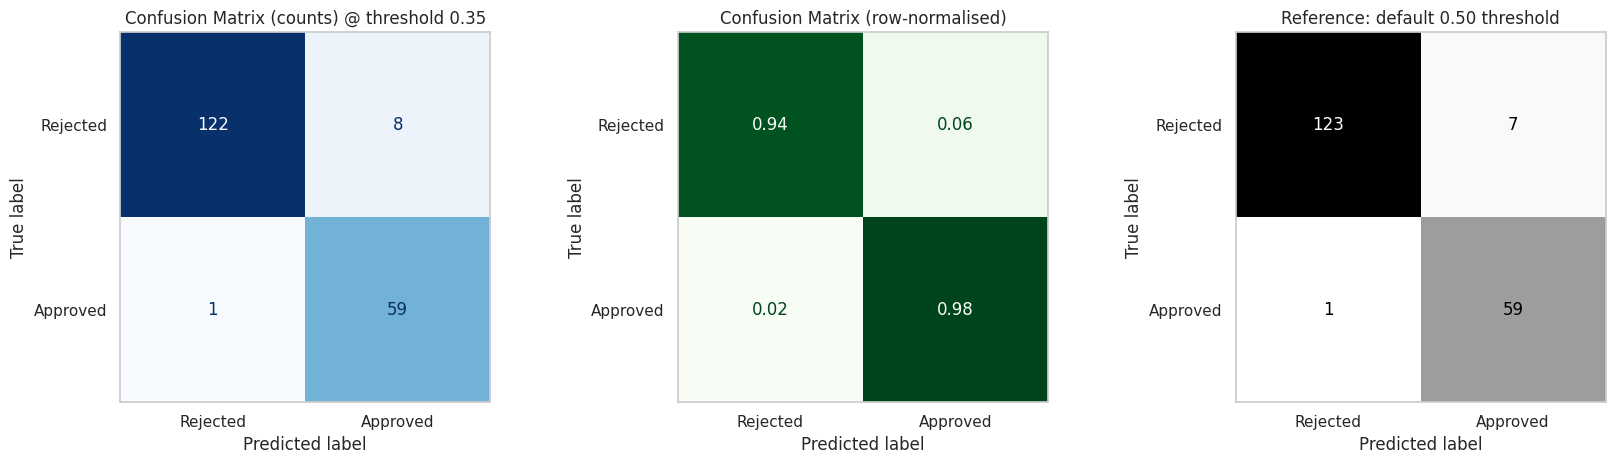

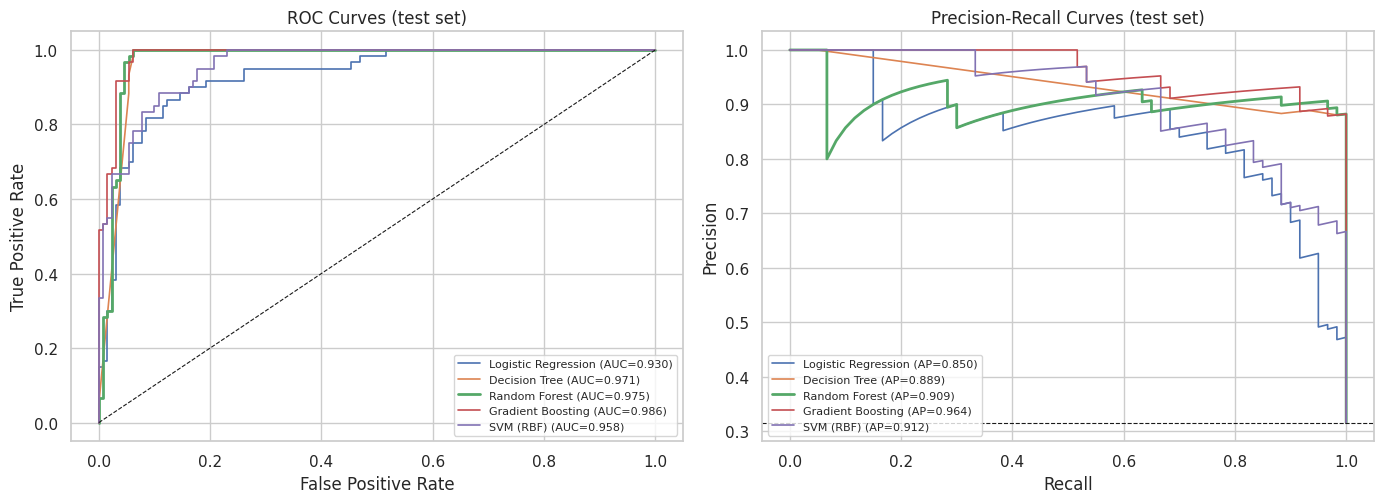

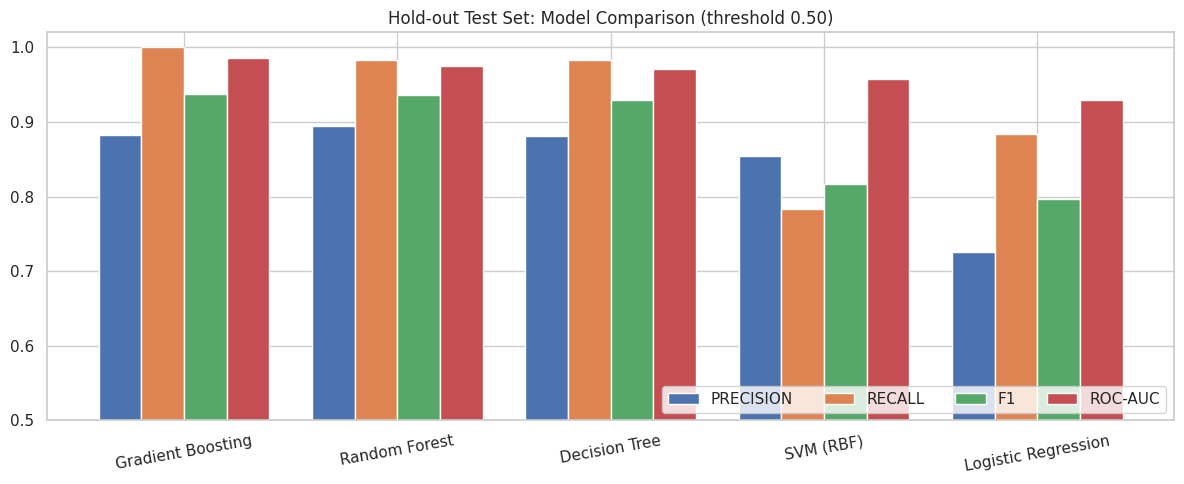

In [8]:
def metrics(yt, p, t):
    pred = (p >= t).astype(int)
    return {"accuracy": accuracy_score(yt, pred), "precision": precision_score(yt, pred, zero_division=0),
            "recall": recall_score(yt, pred), "f1": f1_score(yt, pred), "roc_auc": roc_auc_score(yt, p),
            "pr_auc": average_precision_score(yt, p), "mcc": matthews_corrcoef(yt, pred)}

probs = {n: m.predict_proba(X_te)[:, 1] for n, m in tuned.items()}
test_rows = []
for n, p in probs.items():
    test_rows.append({"Model": n, **metrics(y_te, p, 0.5)})
test_table = pd.DataFrame(test_rows).sort_values("f1", ascending=False).reset_index(drop=True)
final = metrics(y_te, probs[best_name], thr)
final_default = metrics(y_te, probs[best_name], 0.5)
pred_final = (probs[best_name] >= thr).astype(int)
print("\nTEST SET - all tuned models @0.5 threshold\n", test_table.round(3).to_string())
print(f"\nTEST SET - {best_name} @ tuned threshold {thr:.2f}:", {k: round(v, 3) for k, v in final.items()})
print(classification_report(y_te, pred_final, target_names=["Rejected", "Approved"], digits=3))

# confusion matrices
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
cm = confusion_matrix(y_te, pred_final)
ConfusionMatrixDisplay(cm, display_labels=["Rejected", "Approved"]).plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title(f"Confusion Matrix (counts) @ threshold {thr:.2f}")
ConfusionMatrixDisplay(confusion_matrix(y_te, pred_final, normalize="true"), display_labels=["Rejected", "Approved"]).plot(
    ax=ax[1], cmap="Greens", colorbar=False, values_format=".2f")
ax[1].set_title("Confusion Matrix (row-normalised)")
ConfusionMatrixDisplay(confusion_matrix(y_te, (probs[best_name] >= .5).astype(int)), display_labels=["Rejected", "Approved"]).plot(
    ax=ax[2], cmap="Greys", colorbar=False)
ax[2].set_title("Reference: default 0.50 threshold")
for a in ax: a.grid(False)
save("09_confusion_matrix.png")

# ROC + PR curves (all models)
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))
for n, p in probs.items():
    fpr, tpr, _ = roc_curve(y_te, p); ax[0].plot(fpr, tpr, label=f"{n} (AUC={roc_auc_score(y_te, p):.3f})", lw=2 if n == best_name else 1.2)
    pr, rc, _ = precision_recall_curve(y_te, p); ax[1].plot(rc, pr, label=f"{n} (AP={average_precision_score(y_te, p):.3f})", lw=2 if n == best_name else 1.2)
ax[0].plot([0, 1], [0, 1], "k--", lw=.8); ax[0].set_xlabel("False Positive Rate"); ax[0].set_ylabel("True Positive Rate"); ax[0].set_title("ROC Curves (test set)"); ax[0].legend(loc="lower right", fontsize=8)
ax[1].axhline(y_te.mean(), color="k", ls="--", lw=.8); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].set_title("Precision-Recall Curves (test set)"); ax[1].legend(loc="lower left", fontsize=8)
save("10_roc_pr_curves.png")

# test metric bar chart
fig, ax = plt.subplots(figsize=(12, 5))
for i, mt in enumerate(["precision", "recall", "f1", "roc_auc"]):
    ax.bar(np.arange(len(test_table)) + i * .2, test_table[mt], .2, label=mt.upper() if mt != "roc_auc" else "ROC-AUC")
ax.set_xticks(np.arange(len(test_table)) + .3); ax.set_xticklabels(test_table.Model, rotation=10); ax.set_ylim(0.5, 1.02)
ax.set_title("Hold-out Test Set: Model Comparison (threshold 0.50)"); ax.legend(ncol=4, loc="lower right")
save("11_model_comparison_test.png")

## 8. ABLATION: do engineered features help?


Ablation (5-fold CV on train):
                                  precision  recall     f1  roc_auc
Raw features only                    0.913   0.970  0.941    0.984
Raw + engineered banking ratios      0.910   0.971  0.939    0.983


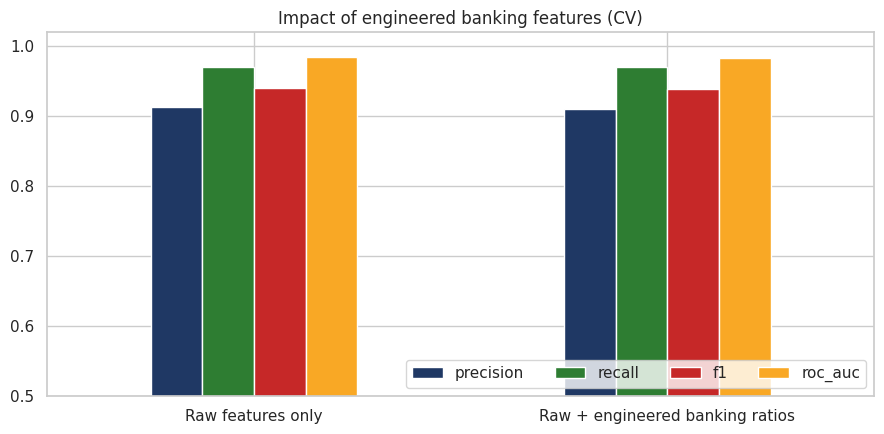

In [9]:
abl = {}
for label, nc in [("Raw features only", BASE_NUM), ("Raw + engineered banking ratios", MODEL_NUM)]:
    est = candidates[best_name][0].__class__(**candidates[best_name][0].get_params())
    est.set_params(**{k.replace("clf__", ""): v for k, v in best.get_params().items() if k.startswith("clf__") and k.replace("clf__", "") in est.get_params()})
    pp = Pipeline([("pre", make_pre(nc, MODEL_CAT)), ("clf", est)])
    r = cross_validate(pp, X_tr, y_tr, cv=cv, scoring=["precision", "recall", "f1", "roc_auc"])
    abl[label] = {k: float(r[f"test_{k}"].mean()) for k in ["precision", "recall", "f1", "roc_auc"]}
abl_df = pd.DataFrame(abl).T
print("\nAblation (5-fold CV on train):\n", abl_df.round(3))
fig, ax = plt.subplots(figsize=(9, 4.5)); abl_df.plot.bar(ax=ax, rot=0, color=[C_MAIN, C_YES, C_NO, "#F9A825"])
ax.set_ylim(0.5, 1.02); ax.set_title("Impact of engineered banking features (CV)"); ax.legend(loc="lower right", ncol=4)
save("12_feature_engineering_ablation.png")

## 9. EXPLAINABILITY

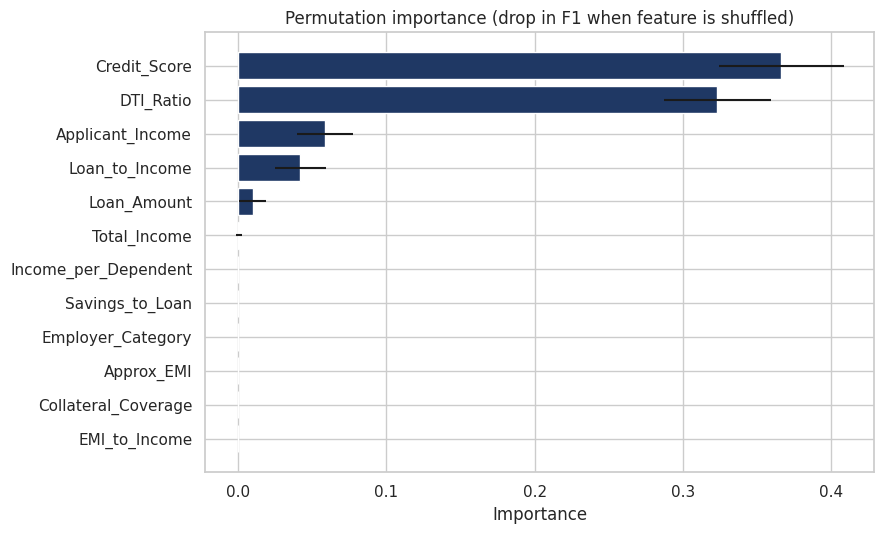

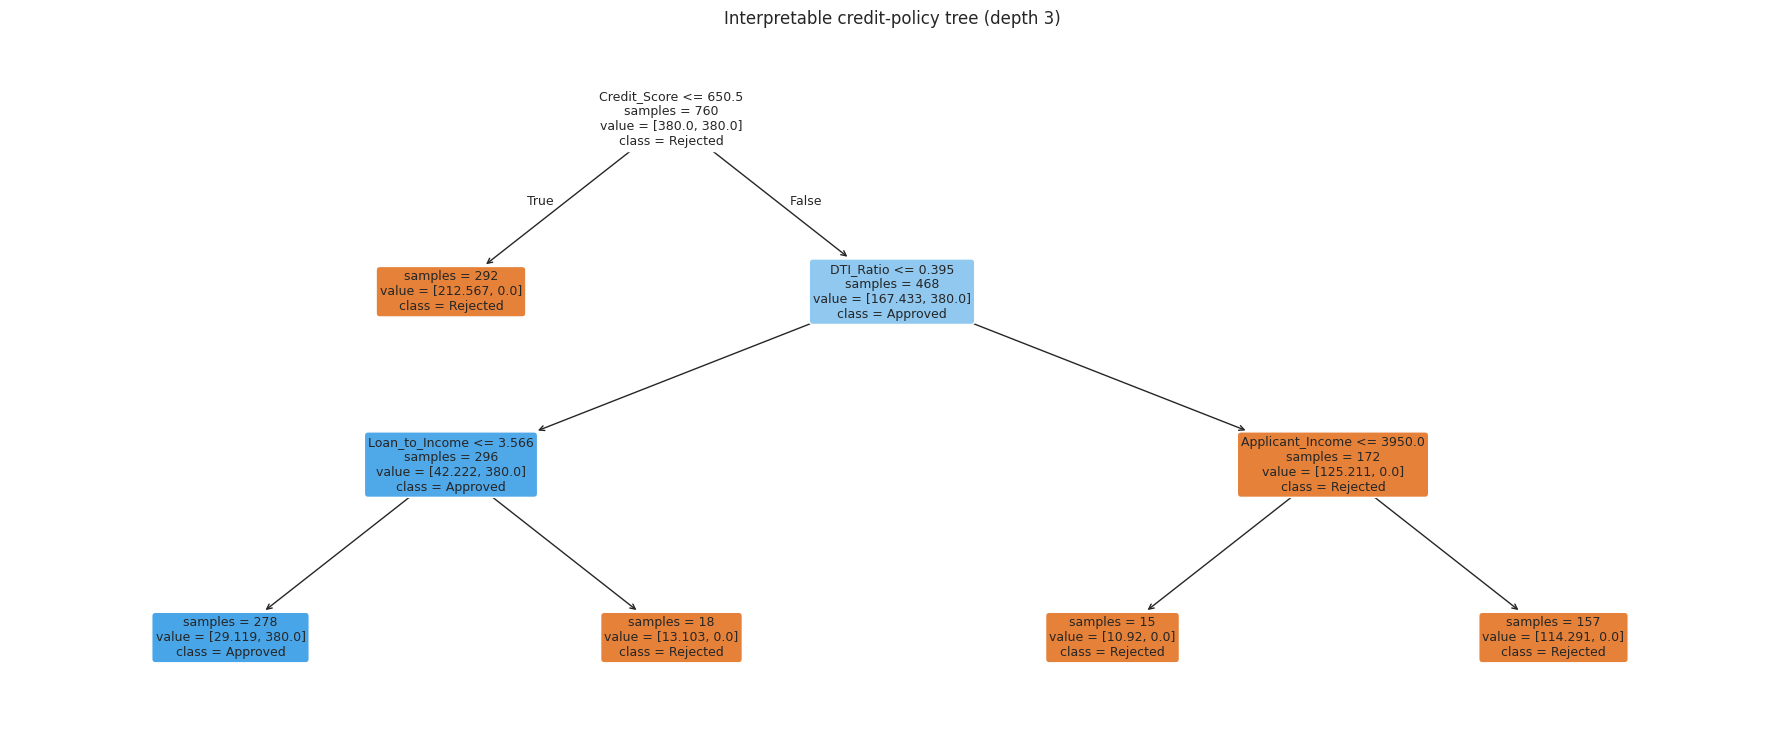


Policy-tree (depth 3) on TEST set: {'precision': 0.833, 'recall': 1.0, 'f1': 0.909, 'confusion_matrix': [[118, 12], [0, 60]]}


In [10]:
pi = permutation_importance(best, X_te, y_te, scoring="f1", n_repeats=30, random_state=SEED, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X_te.columns)
imp = imp[[c for c in X_te.columns if c in MODEL_NUM + MODEL_CAT]].sort_values()
top = imp.tail(12); err = pd.Series(pi.importances_std, index=X_te.columns)[top.index]
plt.figure(figsize=(9, 5.5)); plt.barh(top.index, top.values, xerr=err.values, color=C_MAIN)
plt.title("Permutation importance (drop in F1 when feature is shuffled)"); plt.xlabel("Importance")
save("13_feature_importance.png")

# interpretable shallow tree = readable credit policy
Xi = X_tr[MODEL_NUM].fillna(X_tr[MODEL_NUM].median())
pol = DecisionTreeClassifier(max_depth=3, class_weight="balanced", min_samples_leaf=15, random_state=SEED).fit(Xi, y_tr)
plt.figure(figsize=(18, 7.5))
plot_tree(pol, feature_names=MODEL_NUM, class_names=["Rejected", "Approved"], filled=True, rounded=True, fontsize=9, impurity=False)
plt.title("Interpretable credit-policy tree (depth 3)")
save("14_policy_tree.png")
open(RES_DIR / "policy_tree_rules.txt", "w").write(export_text(pol, feature_names=MODEL_NUM))
pol_pred = pol.predict(X_te[MODEL_NUM].fillna(X_tr[MODEL_NUM].median()))
policy_metrics = {"precision": precision_score(y_te, pol_pred), "recall": recall_score(y_te, pol_pred),
                  "f1": f1_score(y_te, pol_pred), "confusion_matrix": confusion_matrix(y_te, pol_pred).tolist()}
print("\nPolicy-tree (depth 3) on TEST set:", {k: (round(v, 3) if not isinstance(v, list) else v) for k, v in policy_metrics.items()})

## 10. FAIRNESS AUDIT (out-of-fold, full labelled data)


Fairness audit by Gender (model does NOT use Gender):
              n  actual_approval_rate  predicted_approval_rate  recall  \
Gender                                                                  
Female   365.0                 0.342                    0.373   1.000   
Male     538.0                 0.288                    0.335   0.981   
Unknown   47.0                 0.383                    0.426   1.000   

         precision  
Gender              
Female       0.919  
Male         0.844  
Unknown      0.900  


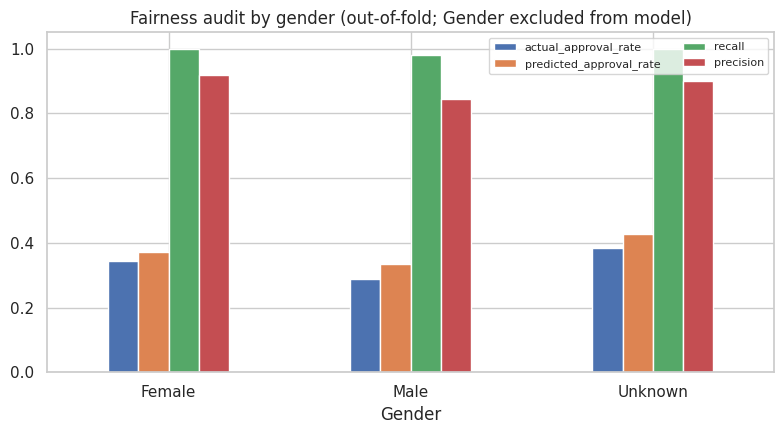

In [11]:
oof_all = cross_val_predict(best, X, y, cv=cv, method="predict_proba")[:, 1]
aud = pd.DataFrame({"Gender": X.Gender.fillna("Unknown"), "y": y, "pred": (oof_all >= thr).astype(int)})
fair = aud.groupby("Gender").apply(lambda g: pd.Series({
    "n": len(g), "actual_approval_rate": g.y.mean(), "predicted_approval_rate": g.pred.mean(),
    "recall": recall_score(g.y, g.pred), "precision": precision_score(g.y, g.pred, zero_division=0)}))
print("\nFairness audit by Gender (model does NOT use Gender):\n", fair.round(3))
fig, ax = plt.subplots(figsize=(8, 4.5)); fair[["actual_approval_rate", "predicted_approval_rate", "recall", "precision"]].plot.bar(ax=ax, rot=0)
ax.set_ylim(0, 1.05); ax.set_title("Fairness audit by gender (out-of-fold; Gender excluded from model)"); ax.legend(ncol=2, fontsize=8)
save("15_fairness_audit.png")

## 11. SAVE ARTEFACTS

In [12]:
joblib.dump({"model": best, "threshold": thr, "features": MODEL_NUM + MODEL_CAT}, MODEL_DIR / "loan_approval_model.joblib")
cv_table.drop(columns="best_params").round(4).to_csv(RES_DIR / "results_cv_comparison.csv", index=False)
test_table.round(4).to_csv(RES_DIR / "results_test_comparison.csv", index=False)
json.dump({"best_model": best_name, "threshold": thr, "best_params": cv_table.loc[0, "best_params"],
           "test_metrics_tuned_threshold": final, "test_metrics_default_threshold": final_default,
           "confusion_matrix": cm.tolist(), "ablation_cv": abl, "policy_tree_test_metrics": policy_metrics,
           "n_labelled": int(len(df)), "n_train": int(len(X_tr)), "n_test": int(len(X_te))},
          open(RES_DIR / "results_summary.json", "w"), indent=2, default=float)
print("\nSaved model, tables and figures.")


Saved model, tables and figures.


## 12. DEMO PREDICTION

In [13]:
def predict_applicant(rec: dict):
    art = joblib.load(MODEL_DIR / "loan_approval_model.joblib")
    d = add_features(pd.DataFrame([rec]))
    p = art["model"].predict_proba(d)[0, 1]
    return {"approval_probability": round(float(p), 3), "decision": "APPROVE" if p >= art["threshold"] else "REJECT"}

demo = dict(Applicant_Income=9500, Coapplicant_Income=3000, Employment_Status="Salaried", Age=34, Marital_Status="Married",
            Dependents=1, Credit_Score=720, Existing_Loans=1, DTI_Ratio=0.25, Savings=12000, Collateral_Value=30000,
            Loan_Amount=18000, Loan_Term=48, Loan_Purpose="Home", Property_Area="Urban", Education_Level="Graduate",
            Gender="Female", Employer_Category="Private")
print("Demo applicant ->", predict_applicant(demo))
weak = dict(demo, Credit_Score=610, DTI_Ratio=0.45)
print("Weak applicant ->", predict_applicant(weak))

Demo applicant -> {'approval_probability': 0.994, 'decision': 'APPROVE'}
Weak applicant -> {'approval_probability': 0.0, 'decision': 'REJECT'}
